In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from Database.TPData import TPData, TPDataDa, TPDataAssembly, Database
from datetime import datetime, time, timedelta

# Loading_fair_price_from_DB

In [59]:
# 1. Read data from source DB
conn = Database('timescaledb')

query=f"""select * from user_andrej_zubal.view_de_instr_2025_fair_prices""" # where rownum <= 100"""

query=f"""
select 
a.*,
b.*
from user_andrej_zubal.view_de_instr_2025_fair_prices a
inner join user_andrej_zubal.alternative_fair_prices b on a.tradeid = b.tradeid and a.datetime = b.datetime;
"""
df_fp=conn.execute(query)

print(f"✅ Loaded {len(df_fp)} rows from source database.")

Connected to the database timescaledb
Disconnected from the database timescaledb
✅ Loaded 887238 rows from source database.


In [60]:
df_fp = df_fp.loc[:, ~df_fp.columns.duplicated()]

In [61]:
df_fp.head()

,datetime,tradeid,ll_dem1_dem2_fair_price,ll_dem1_deq1_fair_price,ll_dem1_dey1_fair_price,ll_dem1_ttfm1_fair_price,ll_dem2_deq1_fair_price,ll_dem2_dey1_fair_price,ll_dem2_ttfm1_fair_price,ll_deq1_dem2_fair_price,...,alternative_fair_price_dem1_dem2_2_10_3,alternative_fair_price_dem1_dem2_4_10_3,alternative_fair_price_dem1_dem2_6_10_3,alternative_fair_price_dem1_dem2_8_10_3,alternative_fair_price_dem1_dem2_10_10_3,alternative_fair_price_dem1_deq1_2_10_3,alternative_fair_price_dem1_deq1_4_10_3,alternative_fair_price_dem1_deq1_6_10_3,alternative_fair_price_dem1_deq1_8_10_3,alternative_fair_price_dem1_deq1_10_10_3
0,2025-01-10 13:28:45,7786785,85.53123339604514,76.19599112421302,89.56615052444587,43.79260502498706,76.28895151598383,89.62541718694989,43.85802471087009,85.59913368524919,...,85.530038,85.532526,85.545822,85.546890,85.528988,76.210264,76.209838,76.217927,76.218192,76.195991
1,2025-01-13 11:47:25,Eurex T7/DEBQ102025-20250113/5284/1,90.4559794678508,80.61221515000761,92.80786207230307,47.07480911452167,80.69406003585284,92.97252388677104,47.04136807519045,90.64151139679834,...,90.475367,90.423499,90.481555,90.485189,90.454255,80.587666,80.595886,80.644870,80.646568,80.612215
2,2025-01-13 17:24:57,Eurex T7/DEBM022025-20250113/13393/1,93.254522919666,82.89664265822677,94.41463020595756,48.447334960346495,82.90409015190032,94.36089221771356,48.469016450153006,93.08235014232866,...,93.250378,93.253159,93.249462,93.248843,93.252065,82.888743,82.882497,82.893679,82.890783,82.896643
3,2025-01-15 11:13:51,Eurex T7/DEBM032025-20250115/4300/1,92.95209393236838,82.54552498622661,94.28985330781879,47.33476825268233,82.4577416660798,94.23059908313317,47.22855961963591,92.81428230453322,...,92.916152,92.944062,92.907972,92.914105,92.928672,82.513067,82.582913,82.557110,82.564354,82.545525
4,2025-01-16 11:32:53,Eurex T7/DEB1022025-20250116/4069/1,90.00166242279255,80.6878730388646,93.40881738461952,46.35651465140766,80.81558798670693,93.3099911649312,46.35490932395152,90.07664367877071,...,89.991326,89.987362,89.997011,89.998563,89.976902,80.690580,80.683534,80.685884,80.687337,80.687873


# dem2

In [62]:
data_class = TPData()
data_class.create_connection('OracleSQL')
data_class_pg = TPData()
data_class_pg.create_connection('PostgreSQL')
data_class_tp = TPDataDa()

mkt_list = ['de']
tenor_list = ['m']
tn_list = [2]
prod = 'base'
venue_list = ['eex']
# start_date = datetime(2024, 6, 3)
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 5, 4)

allwd_broker_ids = [1441]

sample_dates = pd.date_range(start_date, end_date, freq='B')

n = 16
n_t = 15
d_t = 1
date_range_dict = {k.date(): pd.date_range(k, periods=n, freq='B')
                   for k in sample_dates[:-n+1]}

n_s = 2

dates = pd.date_range(start_date, end_date, freq='B')
product_date = [dates.shift(1, freq='B') if t == 'da' else
                dates.shift(1, freq='D') if t == 'd' else
                dates.shift(tn, freq='W-MON') if t == 'w' else
                (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
                (dates + n_s * dates.freq).shift(tn, freq='YS') if t in ['dec'] else
                (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
                for t, tn in zip(tenor_list, tn_list)]

start_time = time(9, 0, 0)
end_time = time(18, 0, 0)

tr_data_dict = {m + t + str(n): [] for m, t, n in zip(mkt_list, tenor_list, tn_list)}
agg_dict = {'price': 'sum', 'volume': 'sum', 'action': 'median',
            'broker_id': 'median', 'count': 'sum'}

for m, t, n, p_dates in zip(mkt_list, tenor_list, tn_list, product_date):
    df_tr, df_ba = pd.DataFrame([]), pd.DataFrame([])
    series = pd.Series(p_dates, index=dates)
    for p_d, ds in list(series.groupby(series).groups.items()):
        bT = datetime.combine(ds[0], start_time)
        eT = datetime.combine(ds[-1], end_time)
        # Trades
        df_tr_aux = data_class.get_trades(m, t, venue_list, p_d, bT, eT, prod)
        # Filter by broker
        if not allwd_broker_ids or t == 'da':
            pass
        else:
            df_tr_aux = df_tr_aux[df_tr_aux['broker_id'].isin(allwd_broker_ids)]
        try:
            df_tr_aux = df_tr_aux.between_time(start_time, end_time)
        except(TypeError):
            pass
        # Group trades
        df_tr_aux['count'] = 1
        #df_tr_aux['price'] *= df_tr_aux['volume']
        #df_tr_aux = df_tr_aux.groupby(df_tr_aux.index).agg(agg_dict)
        #df_tr_aux['price'] /= df_tr_aux['volume']
        df_tr = pd.concat([df_tr, df_tr_aux])
        del df_tr_aux
    tr_data_dict[m + t + str(n)] = df_tr
    
trades2=pd.concat({k: v for k, v in list(tr_data_dict.items())}, axis=1)
trades2.columns = ['_'.join([col[-1], col[0]]) for col in trades2.columns]
trades2.index.name='datetime'
trades2=trades2[['tradeid_dem2', 'price_dem2', 'volume_dem2', 'action_dem2', 'broker_id_dem2']]


trades2.sort_index(inplace=True)

df=trades2.rename(columns={'tradeid_dem2': 'tradeid', 'price_dem2': 'price'})[['tradeid', 'price']].merge(df_fp, how='left', on='tradeid')

Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle


In [63]:
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [64]:
df

,tradeid,price,datetime,ll_dem1_dem2_fair_price,ll_dem1_deq1_fair_price,ll_dem1_dey1_fair_price,ll_dem1_ttfm1_fair_price,ll_dem2_deq1_fair_price,ll_dem2_dey1_fair_price,ll_dem2_ttfm1_fair_price,...,alternative_fair_price_dem1_dem2_2_10_3,alternative_fair_price_dem1_dem2_4_10_3,alternative_fair_price_dem1_dem2_6_10_3,alternative_fair_price_dem1_dem2_8_10_3,alternative_fair_price_dem1_dem2_10_10_3,alternative_fair_price_dem1_deq1_2_10_3,alternative_fair_price_dem1_deq1_4_10_3,alternative_fair_price_dem1_deq1_6_10_3,alternative_fair_price_dem1_deq1_8_10_3,alternative_fair_price_dem1_deq1_10_10_3
0,Eurex T7/DEBM032025-20250102/858/1,97.86,2025-01-02 09:01:18,98.045234528694,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Eurex T7/DEBM032025-20250102/891/2,97.75,2025-01-02 09:02:33,98.045234528694,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Eurex T7/DEBM032025-20250102/915/1,97.71,2025-01-02 09:03:46,97.93561944401829,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Eurex T7/DEBM032025-20250102/920/1,97.82,2025-01-02 09:04:27,97.9425568873187,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Eurex T7/DEBM032025-20250102/921/1,97.81,2025-01-02 09:04:27,97.9425568873187,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91309,Eurex T7/DEBM072025-20250430/9305/1,72.10,2025-04-30 16:57:27,72.00753155414355,75.0566913439967,81.21396045775317,32.31757296341671,75.25355714418963,81.20439117373321,32.35916611084707,...,71.996862,71.994635,71.927736,71.928463,71.999575,75.141147,75.205809,75.122025,75.119981,75.056691
91310,Eurex T7/DEBM072025-20250430/9307/1,72.10,2025-04-30 16:57:38,72.00753155414355,75.0566913439967,81.21396045775317,32.31757296341671,75.25355714418963,81.20439117373321,32.35916611084707,...,71.996862,71.994635,71.927736,71.928463,71.999575,75.141147,75.205809,75.122025,75.119981,75.056691
91311,Eurex T7/DEBM072025-20250430/9308/1,72.10,2025-04-30 16:57:38,72.00753155414355,75.0566913439967,81.21396045775317,32.31757296341671,75.25355714418963,81.20439117373321,32.35916611084707,...,71.996862,71.994635,71.927736,71.928463,71.999575,75.141147,75.205809,75.122025,75.119981,75.056691
91312,Eurex T7/DEBM072025-20250430/9311/1,72.10,2025-04-30 16:57:41,72.14944636352034,75.08052786789752,81.25997343409742,32.351495285389255,75.25355714418963,81.20439117373321,32.35916611084707,...,71.996862,71.994635,72.144363,72.144816,72.142827,75.164528,75.230727,75.150129,75.145695,75.080528


C:\Users\andrej\AppData\Local\Temp\ipykernel_2888\258424422.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')


,ll_dem1_dem2_fair_price,ll_deq1_dem2_fair_price,ll_ttfm1_dem2_fair_price,ll_aux_dem1_dem2_fair_price,ll_aux_deq1_dem2_fair_price,ll_aux_dey1_dem2_fair_price,ll_aux_ens_dem2_fair_price,prev_price
month,,,,,,,,
2025-01,0.056594,0.109174,0.115270,0.053721,0.080904,0.103587,0.029662,0.05
2025-02,0.064720,0.099249,0.108018,0.058324,0.086642,0.111346,0.031556,0.05
2025-03,0.060860,0.093724,0.096249,0.059206,0.084692,0.095647,0.031005,0.05
2025-04,0.053331,0.088363,0.088780,0.046939,0.069941,0.079826,0.025606,0.04


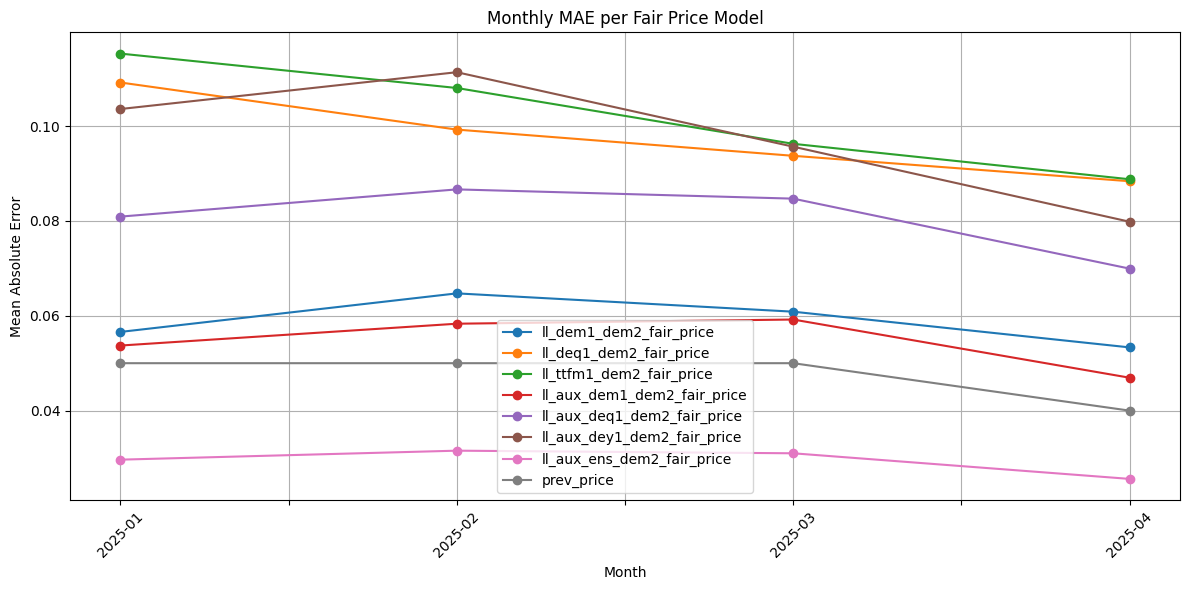

In [65]:
# Extract month
df['month'] = df['datetime'].dt.to_period('M').astype(str)
df['prev_price'] = df['price'].shift(1)
df=df[abs(df['prev_price']-df['price'])>0.01]

# Identify all fair_price columns
fair_price_cols = [col for col in df.columns if 'dem2_fair_price' in col]+['prev_price']

# Convert Decimal columns to float
df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')

# Container for MAE results
mae_dict = {}

for col in fair_price_cols:
    df_temp = df[['month', 'price', col]].dropna()
    df_temp['abs_error'] = (df_temp['price'] - df_temp[col]).abs()
    mae = df_temp.groupby('month')['abs_error'].median()
    mae_dict[col] = mae

# Combine into single DataFrame
mae_df = pd.DataFrame(mae_dict)

# Plot
mae_df.plot(figsize=(12, 6), marker='o')
plt.title("Monthly MAE per Fair Price Model")
plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show table too
mae_df.head()

In [66]:
mae_df.mean().sort_values(ascending=True)

ll_aux_ens_dem2_fair_price     0.029457
prev_price                     0.047500
ll_aux_dem1_dem2_fair_price    0.054547
ll_dem1_dem2_fair_price        0.058876
ll_aux_deq1_dem2_fair_price    0.080545
ll_aux_dey1_dem2_fair_price    0.097602
ll_deq1_dem2_fair_price        0.097628
ll_ttfm1_dem2_fair_price       0.102079
dtype: float64

# deq1

In [67]:
data_class = TPData()
data_class.create_connection('OracleSQL')
data_class_pg = TPData()
data_class_pg.create_connection('PostgreSQL')
data_class_tp = TPDataDa()

mkt_list = ['de']
tenor_list = ['q']
tn_list = [1]
prod = 'base'
venue_list = ['eex']
# start_date = datetime(2024, 6, 3)
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 5, 4)

allwd_broker_ids = [1441]

sample_dates = pd.date_range(start_date, end_date, freq='B')

n = 16
n_t = 15
d_t = 1
date_range_dict = {k.date(): pd.date_range(k, periods=n, freq='B')
                   for k in sample_dates[:-n+1]}

n_s = 2

dates = pd.date_range(start_date, end_date, freq='B')
product_date = [dates.shift(1, freq='B') if t == 'da' else
                dates.shift(1, freq='D') if t == 'd' else
                dates.shift(tn, freq='W-MON') if t == 'w' else
                (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
                (dates + n_s * dates.freq).shift(tn, freq='YS') if t in ['dec'] else
                (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
                for t, tn in zip(tenor_list, tn_list)]

start_time = time(9, 0, 0)
end_time = time(18, 0, 0)

tr_data_dict = {m + t + str(n): [] for m, t, n in zip(mkt_list, tenor_list, tn_list)}
agg_dict = {'price': 'sum', 'volume': 'sum', 'action': 'median',
            'broker_id': 'median', 'count': 'sum'}

for m, t, n, p_dates in zip(mkt_list, tenor_list, tn_list, product_date):
    df_tr, df_ba = pd.DataFrame([]), pd.DataFrame([])
    series = pd.Series(p_dates, index=dates)
    for p_d, ds in list(series.groupby(series).groups.items()):
        bT = datetime.combine(ds[0], start_time)
        eT = datetime.combine(ds[-1], end_time)
        # Trades
        df_tr_aux = data_class.get_trades(m, t, venue_list, p_d, bT, eT, prod)
        # Filter by broker
        if not allwd_broker_ids or t == 'da':
            pass
        else:
            df_tr_aux = df_tr_aux[df_tr_aux['broker_id'].isin(allwd_broker_ids)]
        try:
            df_tr_aux = df_tr_aux.between_time(start_time, end_time)
        except(TypeError):
            pass
        # Group trades
        df_tr_aux['count'] = 1
        #df_tr_aux['price'] *= df_tr_aux['volume']
        #df_tr_aux = df_tr_aux.groupby(df_tr_aux.index).agg(agg_dict)
        #df_tr_aux['price'] /= df_tr_aux['volume']
        df_tr = pd.concat([df_tr, df_tr_aux])
        del df_tr_aux
    tr_data_dict[m + t + str(n)] = df_tr
    
trades2=pd.concat({k: v for k, v in list(tr_data_dict.items())}, axis=1)
trades2.columns = ['_'.join([col[-1], col[0]]) for col in trades2.columns]
trades2.index.name='datetime'
trades2=trades2[['tradeid_deq1', 'price_deq1', 'volume_deq1', 'action_deq1', 'broker_id_deq1']]


trades2.sort_index(inplace=True)

df=trades2.rename(columns={'tradeid_deq1': 'tradeid', 'price_deq1': 'price'})[['tradeid', 'price']].merge(df_fp, how='left', on='tradeid')

Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle


In [68]:
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [69]:
df

,tradeid,price,datetime,ll_dem1_dem2_fair_price,ll_dem1_deq1_fair_price,ll_dem1_dey1_fair_price,ll_dem1_ttfm1_fair_price,ll_dem2_deq1_fair_price,ll_dem2_dey1_fair_price,ll_dem2_ttfm1_fair_price,...,alternative_fair_price_dem1_dem2_2_10_3,alternative_fair_price_dem1_dem2_4_10_3,alternative_fair_price_dem1_dem2_6_10_3,alternative_fair_price_dem1_dem2_8_10_3,alternative_fair_price_dem1_dem2_10_10_3,alternative_fair_price_dem1_deq1_2_10_3,alternative_fair_price_dem1_deq1_4_10_3,alternative_fair_price_dem1_deq1_6_10_3,alternative_fair_price_dem1_deq1_8_10_3,alternative_fair_price_dem1_deq1_10_10_3
0,Eurex T7/DEBQ042025-20250102/849/1,82.00,2025-01-02 09:00:55,98.045234528694,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Eurex T7/DEBQ042025-20250102/994/1,82.06,2025-01-02 09:06:52,97.88023323865758,None,None,None,None,None,None,...,97.877734,97.878578,97.880815,97.879333,97.891422,NaN,NaN,NaN,NaN,NaN
2,Eurex T7/DEBQ042025-20250102/1000/1,82.15,2025-01-02 09:07:34,97.86638147546684,None,None,None,None,None,None,...,97.864788,97.865232,97.867271,97.865789,97.875773,NaN,NaN,NaN,NaN,NaN
3,Eurex T7/DEBQ042025-20250102/1048/2,82.30,2025-01-02 09:12:04,97.91376012341124,None,None,None,None,None,None,...,97.908713,97.956062,97.934817,97.934799,97.916539,NaN,NaN,NaN,NaN,NaN
4,Eurex T7/DEBQ042025-20250102/1050/2,82.35,2025-01-02 09:12:11,97.91376012341124,None,None,None,None,None,None,...,97.908713,97.956062,97.934817,97.934799,97.916539,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72318,Eurex T7/DEBQ072025-20250430/9276/1,75.15,2025-04-30 16:55:26,72.00067464415305,75.05139115505412,81.20373076262425,32.28255031279835,75.28403930384393,81.22687870436184,32.35916611084707,...,71.996862,71.994635,71.927736,71.928463,71.993852,75.035380,75.021930,75.057969,75.054853,75.051391
72319,Eurex T7/DEBQ072025-20250430/9299/1,75.14,2025-04-30 16:57:16,71.9869568319067,75.04078729970583,81.18326636021989,32.29495334181606,75.28403930384393,81.22687870436184,32.35916611084707,...,71.996862,71.994635,71.927736,71.928463,71.982402,75.125547,75.010871,75.045477,75.043423,75.040787
72320,Eurex T7/DEBQ072025-20250430/9322/1,75.25,2025-04-30 16:58:50,72.15630652834112,75.08582169307581,81.27019395517051,32.35903242155632,75.25355714418963,81.20439117373321,32.35916611084707,...,71.996862,71.994635,72.149450,72.149949,72.148552,75.169720,75.236261,75.156370,75.151406,75.085822
72321,Eurex T7/DEBQ072025-20250430/9327/1,75.15,2025-04-30 16:58:58,72.11855916547276,75.0566913439967,81.21396045775317,32.33410103224636,75.25355714418963,81.20439117373321,32.326840248190294,...,72.076347,72.078170,72.073470,72.073427,72.117045,75.148942,75.205809,75.122025,75.119981,75.056691


C:\Users\andrej\AppData\Local\Temp\ipykernel_2888\4224258777.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')


,ll_dem1_deq1_fair_price,ll_dem2_deq1_fair_price,ll_ttfm1_deq1_fair_price,ll_aux_dem1_deq1_fair_price,ll_aux_dem2_deq1_fair_price,ll_aux_dey1_deq1_fair_price,ll_aux_ens_deq1_fair_price,prev_price
month,,,,,,,,
2025-01,0.072533,0.087046,0.094118,0.068709,0.088229,0.094107,0.030737,0.05
2025-02,0.081447,0.110847,0.100183,0.075783,0.099850,0.110031,0.034277,0.05
2025-03,0.077153,0.109918,0.097327,0.073988,0.104213,0.110686,0.036831,0.05
2025-04,0.078458,0.094454,0.092586,0.071263,0.085318,0.089090,0.031337,0.05


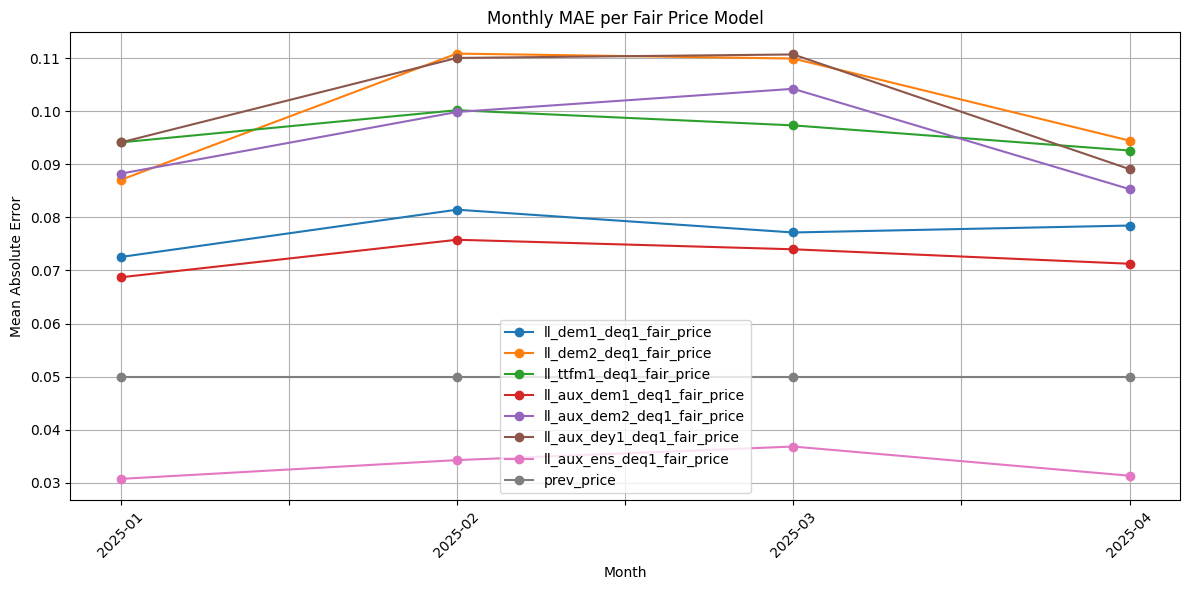

In [70]:
# Extract month
df['month'] = df['datetime'].dt.to_period('M').astype(str)
df['prev_price'] = df['price'].shift(1)
df=df[abs(df['prev_price']-df['price'])>0.01]

# Identify all fair_price columns
fair_price_cols = [col for col in df.columns if  'deq1_fair_price' in col]+['prev_price']

# Convert Decimal columns to float
df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')

# Container for MAE results
mae_dict = {}

for col in fair_price_cols:
    df_temp = df[['month', 'price', col]].dropna()
    df_temp['abs_error'] = (df_temp['price'] - df_temp[col]).abs()
    mae = df_temp.groupby('month')['abs_error'].median()
    mae_dict[col] = mae

# Combine into single DataFrame
mae_df = pd.DataFrame(mae_dict)

# Plot
mae_df.plot(figsize=(12, 6), marker='o')
plt.title("Monthly MAE per Fair Price Model")
plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show table too
mae_df.head()

In [71]:
mae_df.mean().sort_values(ascending=True)

ll_aux_ens_deq1_fair_price     0.033295
prev_price                     0.050000
ll_aux_dem1_deq1_fair_price    0.072436
ll_dem1_deq1_fair_price        0.077398
ll_aux_dem2_deq1_fair_price    0.094402
ll_ttfm1_deq1_fair_price       0.096053
ll_dem2_deq1_fair_price        0.100566
ll_aux_dey1_deq1_fair_price    0.100978
dtype: float64

# dey1

In [72]:
data_class = TPData()
data_class.create_connection('OracleSQL')
data_class_pg = TPData()
data_class_pg.create_connection('PostgreSQL')
data_class_tp = TPDataDa()

mkt_list = ['de']
tenor_list = ['y']
tn_list = [1]
prod = 'base'
venue_list = ['eex']
# start_date = datetime(2024, 6, 3)
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 5, 4)

allwd_broker_ids = [1441]

sample_dates = pd.date_range(start_date, end_date, freq='B')

n = 16
n_t = 15
d_t = 1
date_range_dict = {k.date(): pd.date_range(k, periods=n, freq='B')
                   for k in sample_dates[:-n+1]}

n_s = 2

dates = pd.date_range(start_date, end_date, freq='B')
product_date = [dates.shift(1, freq='B') if t == 'da' else
                dates.shift(1, freq='D') if t == 'd' else
                dates.shift(tn, freq='W-MON') if t == 'w' else
                (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
                (dates + n_s * dates.freq).shift(tn, freq='YS') if t in ['dec'] else
                (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
                for t, tn in zip(tenor_list, tn_list)]

start_time = time(9, 0, 0)
end_time = time(18, 0, 0)

tr_data_dict = {m + t + str(n): [] for m, t, n in zip(mkt_list, tenor_list, tn_list)}
agg_dict = {'price': 'sum', 'volume': 'sum', 'action': 'median',
            'broker_id': 'median', 'count': 'sum'}

for m, t, n, p_dates in zip(mkt_list, tenor_list, tn_list, product_date):
    df_tr, df_ba = pd.DataFrame([]), pd.DataFrame([])
    series = pd.Series(p_dates, index=dates)
    for p_d, ds in list(series.groupby(series).groups.items()):
        bT = datetime.combine(ds[0], start_time)
        eT = datetime.combine(ds[-1], end_time)
        # Trades
        df_tr_aux = data_class.get_trades(m, t, venue_list, p_d, bT, eT, prod)
        # Filter by broker
        if not allwd_broker_ids or t == 'da':
            pass
        else:
            df_tr_aux = df_tr_aux[df_tr_aux['broker_id'].isin(allwd_broker_ids)]
        try:
            df_tr_aux = df_tr_aux.between_time(start_time, end_time)
        except(TypeError):
            pass
        # Group trades
        df_tr_aux['count'] = 1
        #df_tr_aux['price'] *= df_tr_aux['volume']
        #df_tr_aux = df_tr_aux.groupby(df_tr_aux.index).agg(agg_dict)
        #df_tr_aux['price'] /= df_tr_aux['volume']
        df_tr = pd.concat([df_tr, df_tr_aux])
        del df_tr_aux
    tr_data_dict[m + t + str(n)] = df_tr
    
trades2=pd.concat({k: v for k, v in list(tr_data_dict.items())}, axis=1)
trades2.columns = ['_'.join([col[-1], col[0]]) for col in trades2.columns]
trades2.index.name='datetime'
trades2=trades2[['tradeid_dey1', 'price_dey1', 'volume_dey1', 'action_dey1', 'broker_id_dey1']]


trades2.sort_index(inplace=True)

df=trades2.rename(columns={'tradeid_dey1': 'tradeid', 'price_dey1': 'price'})[['tradeid', 'price']].merge(df_fp, how='left', on='tradeid')

Connected to the database oracle
Disconnected from the database oracle


In [73]:
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [74]:
df

,tradeid,price,datetime,ll_dem1_dem2_fair_price,ll_dem1_deq1_fair_price,ll_dem1_dey1_fair_price,ll_dem1_ttfm1_fair_price,ll_dem2_deq1_fair_price,ll_dem2_dey1_fair_price,ll_dem2_ttfm1_fair_price,...,alternative_fair_price_dem1_dem2_2_10_3,alternative_fair_price_dem1_dem2_4_10_3,alternative_fair_price_dem1_dem2_6_10_3,alternative_fair_price_dem1_dem2_8_10_3,alternative_fair_price_dem1_dem2_10_10_3,alternative_fair_price_dem1_deq1_2_10_3,alternative_fair_price_dem1_deq1_4_10_3,alternative_fair_price_dem1_deq1_6_10_3,alternative_fair_price_dem1_deq1_8_10_3,alternative_fair_price_dem1_deq1_10_10_3
0,Eurex T7/DEBY012026-20250102/948/2,90.00,2025-01-02 09:05:12,97.78257002449372,None,None,None,None,None,None,...,97.793286,97.793119,97.792929,97.792910,97.793349,NaN,NaN,NaN,NaN,NaN
1,Eurex T7/DEBY012026-20250102/982/2,90.11,2025-01-02 09:05:38,97.7971160876331,None,None,None,None,None,None,...,97.800049,97.798495,97.799542,97.798065,97.797526,NaN,NaN,NaN,NaN,NaN
2,Eurex T7/DEBY012026-20250102/1028/1,90.10,2025-01-02 09:10:18,98.01076020918475,None,None,None,None,None,None,...,97.999366,97.979702,98.006757,98.006733,98.026123,NaN,NaN,NaN,NaN,NaN
3,Eurex T7/DEBY012026-20250102/1029/1,90.15,2025-01-02 09:10:18,98.01076020918475,None,None,None,None,None,None,...,97.999366,97.979702,98.006757,98.006733,98.026123,NaN,NaN,NaN,NaN,NaN
4,Eurex T7/DEBY012026-20250102/1034/1,90.20,2025-01-02 09:11:23,97.92068941270598,None,None,None,None,None,None,...,97.915189,97.892945,97.918690,97.918670,97.924367,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42747,Eurex T7/DEBY012026-20250430/8780/1,81.38,2025-04-30 16:38:10,72.37887617037094,75.46692231389878,81.24629836335383,32.276126685754214,75.48905737695308,81.35354896833853,32.25683852574015,...,72.263996,72.268179,72.257911,72.257543,72.380945,75.474433,75.456819,75.449856,75.450121,75.466922
42748,Eurex T7/DEBY012026-20250430/8847/1,81.28,2025-04-30 16:41:09,72.33416891513325,75.4323519819845,81.17992182437372,32.22730266096677,75.4037483948229,81.29068000806492,32.2089806956044,...,72.233879,72.240256,72.224809,72.224139,72.343624,75.440558,75.420757,75.409145,75.412868,75.432352
42749,Eurex T7/DEBY012026-20250430/9216/1,81.30,2025-04-30 16:52:41,71.86414431032313,75.02752595419994,81.1576764516359,32.219232532204394,75.01360162400744,81.02866611414213,32.29267418773154,...,71.989911,71.993297,71.887099,71.887454,71.865013,75.012002,75.012818,75.029855,75.029129,75.027526
42750,Eurex T7/DEBY012026-20250430/9217/1,81.30,2025-04-30 16:52:41,71.86414431032313,75.02752595419994,81.1576764516359,32.219232532204394,75.01360162400744,81.02866611414213,32.29267418773154,...,71.989911,71.993297,71.887099,71.887454,71.865013,75.012002,75.012818,75.029855,75.029129,75.027526


C:\Users\andrej\AppData\Local\Temp\ipykernel_2888\1757343628.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')


,ll_dem1_dey1_fair_price,ll_dem2_dey1_fair_price,ll_deq1_dey1_fair_price,ll_ttfm1_dey1_fair_price,ll_aux_dem1_dey1_fair_price,ll_aux_deq1_dey1_fair_price,ll_aux_dem2_dey1_fair_price,prev_price
month,,,,,,,,
2025-01,0.090750,0.104869,0.095422,0.095761,0.082233,0.099937,0.105621,0.05
2025-02,0.082681,0.104864,0.096931,0.087235,0.074538,0.088278,0.094563,0.05
2025-03,0.083486,0.108677,0.103406,0.088247,0.082809,0.093590,0.101490,0.05
2025-04,0.080498,0.098448,0.087755,0.082212,0.071260,0.085067,0.084247,0.05


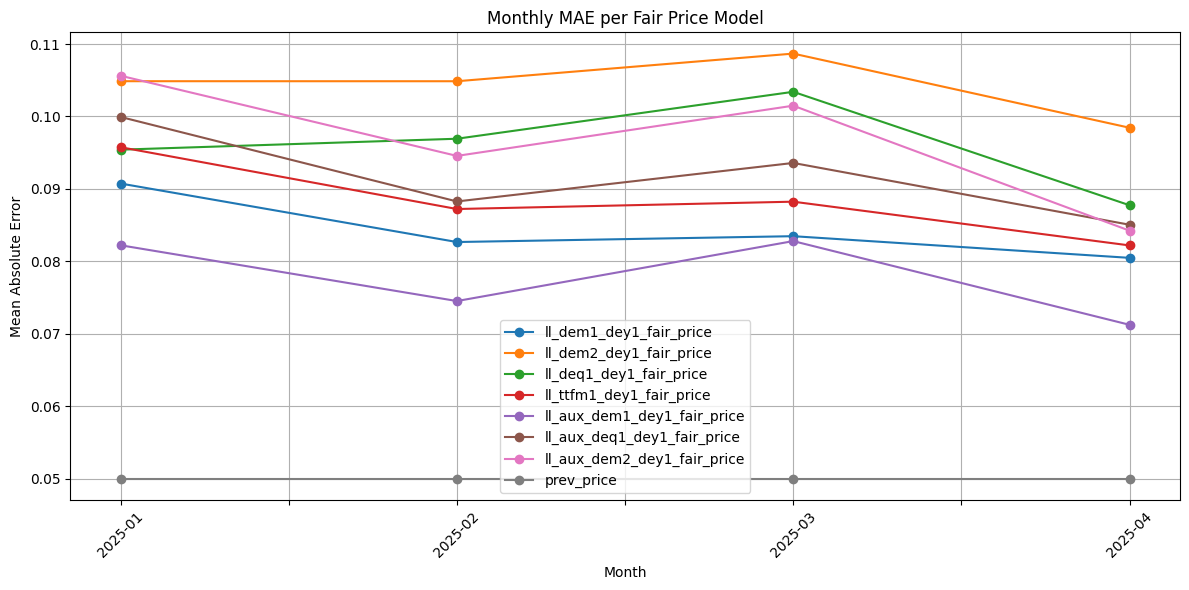

In [75]:
# Extract month
df['month'] = df['datetime'].dt.to_period('M').astype(str)
df['prev_price'] = df['price'].shift(1)
df=df[abs(df['prev_price']-df['price'])>0.01]

# Identify all fair_price columns
fair_price_cols = [col for col in df.columns  if 'dey1_fair_price' in col]+['prev_price']

# Convert Decimal columns to float
df[fair_price_cols] = df[fair_price_cols].apply(pd.to_numeric, errors='coerce')

# Container for MAE results
mae_dict = {}

for col in fair_price_cols:
    df_temp = df[['month', 'price', col]].dropna()
    df_temp['abs_error'] = (df_temp['price'] - df_temp[col]).abs()
    mae = df_temp.groupby('month')['abs_error'].median()
    mae_dict[col] = mae

# Combine into single DataFrame
mae_df = pd.DataFrame(mae_dict)

# Plot
mae_df.plot(figsize=(12, 6), marker='o')
plt.title("Monthly MAE per Fair Price Model")
plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Show table too
mae_df.head()

In [76]:
mae_df.mean().sort_values(ascending=True)

prev_price                     0.050000
ll_aux_dem1_dey1_fair_price    0.077710
ll_dem1_dey1_fair_price        0.084354
ll_ttfm1_dey1_fair_price       0.088364
ll_aux_deq1_dey1_fair_price    0.091718
ll_deq1_dey1_fair_price        0.095879
ll_aux_dem2_dey1_fair_price    0.096480
ll_dem2_dey1_fair_price        0.104214
dtype: float64